<a href="https://colab.research.google.com/github/Agwora/Agwora/blob/main/TimeseriesModels_Classwork(python).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BOX-JENKINS METHODOLOGY FOR TIME SERIES ANALYSIS

STEP 1: Loading Time Series Data
----------------------------------------
Data loaded: 200 observations
Date range: 2020-01-01 00:00:00 to 2020-07-18 00:00:00

STEP 2: Testing for Stationarity
----------------------------------------

Original Series - Augmented Dickey-Fuller Test:
ADF Statistic: -4.4109
p-value: 0.0003
Critical Values:
	1%: -3.4643
	5%: -2.8765
	10%: -2.5747
=> Series is stationary

STEP 3: Model Identification
----------------------------------------


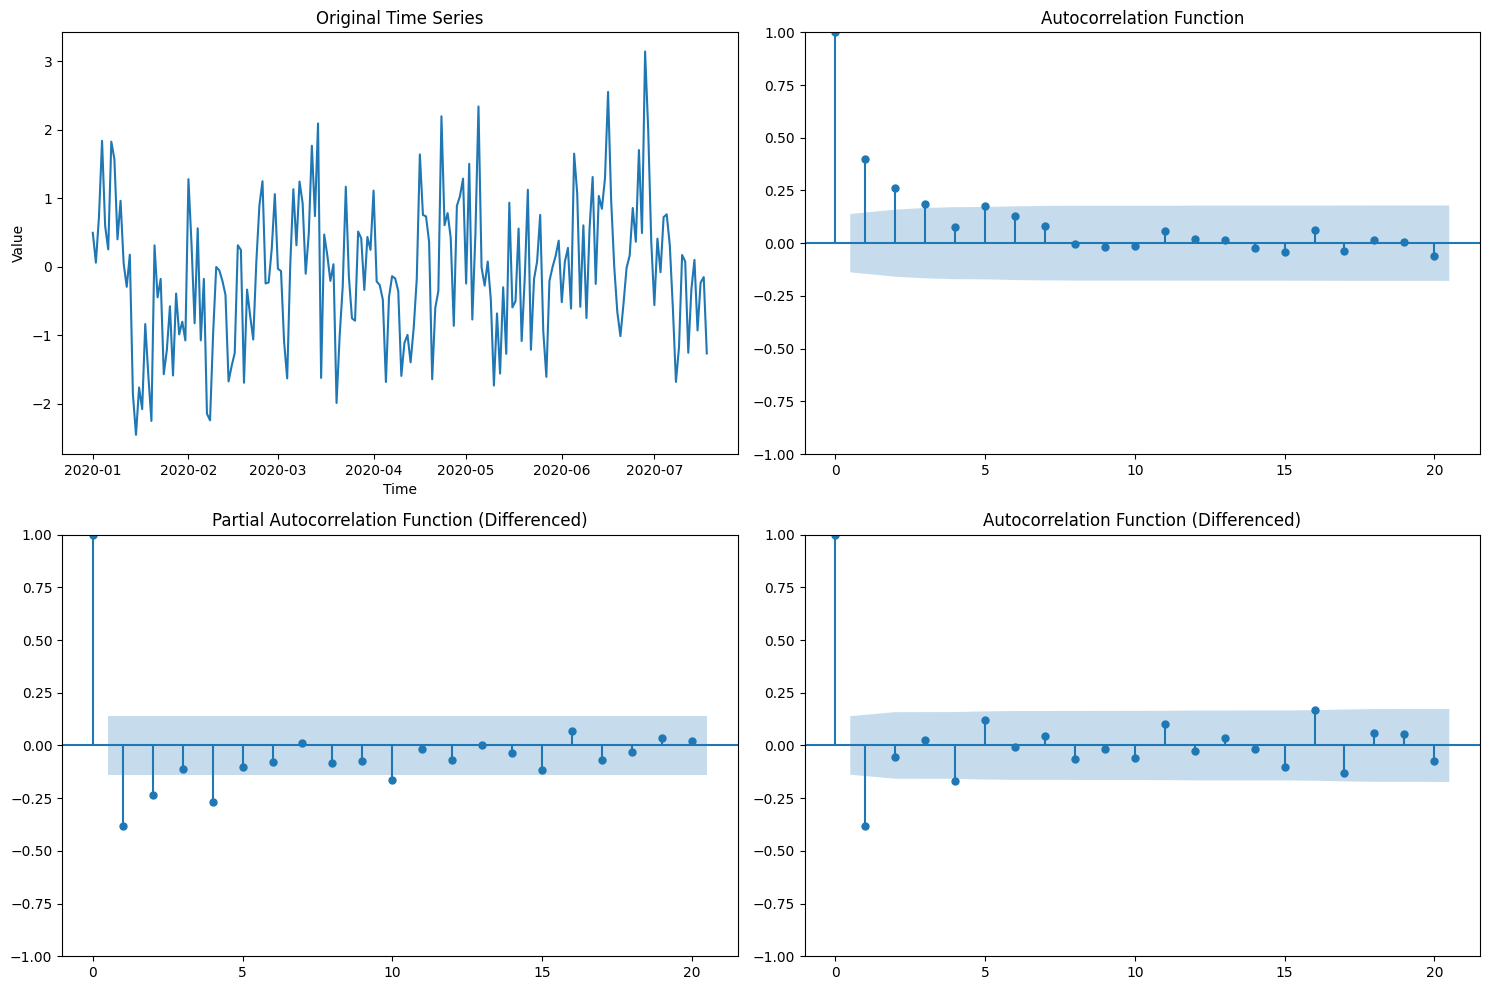


STEP 4: Model Estimation and Fitting
----------------------------------------

FITTING DIFFERENT TIME SERIES MODELS

AR Model (Order [1]):
AIC: 437.26, BIC: 446.46, RMSE: 1.0972

MA Model (Order q=1):
AIC: 444.36, BIC: 453.58, RMSE: 1.0979

ARMA Model (p=1, q=1):
AIC: 438.42, BIC: 450.72, RMSE: 1.0828

ARIMA Model (Order (1, 0, 1)):
AIC: 438.42, BIC: 450.72, RMSE: 1.0828


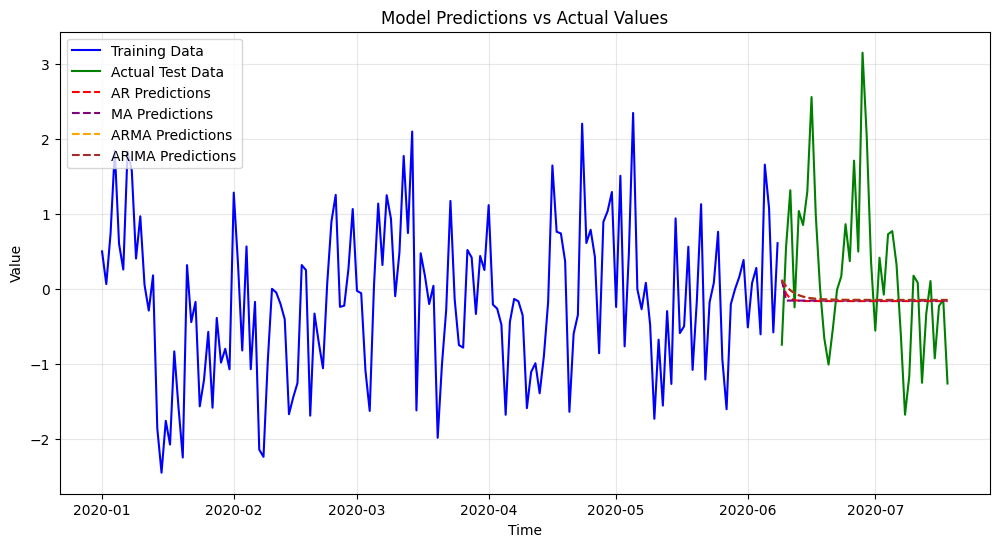


AR Model Equation:
----------------------------------------
Y_t = -0.1067 + 0.3579Y_{t-1} + ε_t

Parameter Significance:
  const: -0.1067 (p=0.1575)
  y.L1: 0.3579 (p=0.0000)***

MA Model Equation:
----------------------------------------
Y_t = -0.1596 + ε_t + 0.2944ε_{t-1}

Parameter Significance:
  const: -0.1596 (p=0.1015)
  ma.L1: 0.2944 (p=0.0001)***
  sigma2: 0.9060 (p=0.0000)***

ARMA Model Equation:
----------------------------------------
Y_t = -0.1506 + 0.6995Y_{t-1} + ε_t + -0.4065ε_{t-1}

Parameter Significance:
  const: -0.1506 (p=0.2974)
  ar.L1: 0.6995 (p=0.0000)***
  ma.L1: -0.4065 (p=0.0481)**
  sigma2: 0.8616 (p=0.0000)***

ARIMA Model Equation:
----------------------------------------
Y_t = -0.1506 + 0.6995Y_{t-1} + ε_t + -0.4065ε_{t-1}

Parameter Significance:
  const: -0.1506 (p=0.2974)
  ar.L1: 0.6995 (p=0.0000)***
  ma.L1: -0.4065 (p=0.0481)**
  sigma2: 0.8616 (p=0.0000)***

STEP 5: Diagnostic Checking
----------------------------------------

Checking residuals

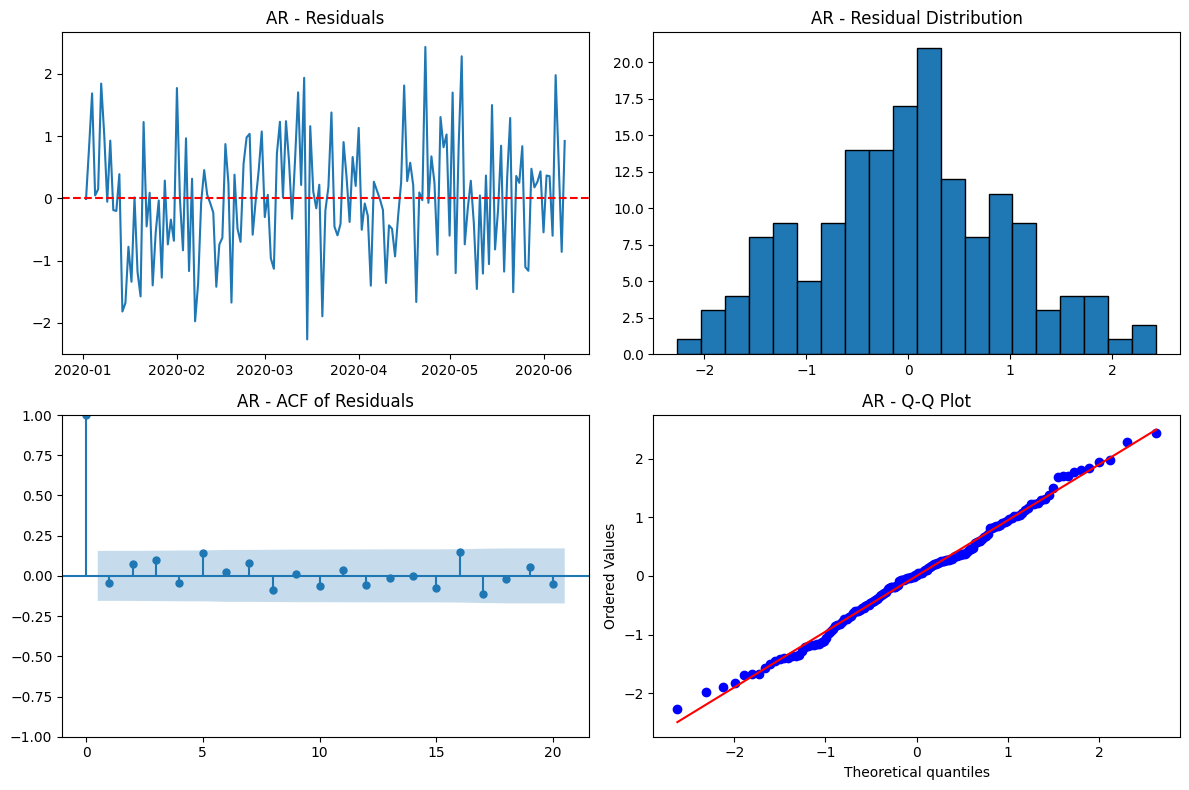


AR - Ljung-Box Test Results:
      lb_stat  lb_pvalue
10   9.721878   0.465223
20  18.900386   0.528309

Checking residuals for MA model:


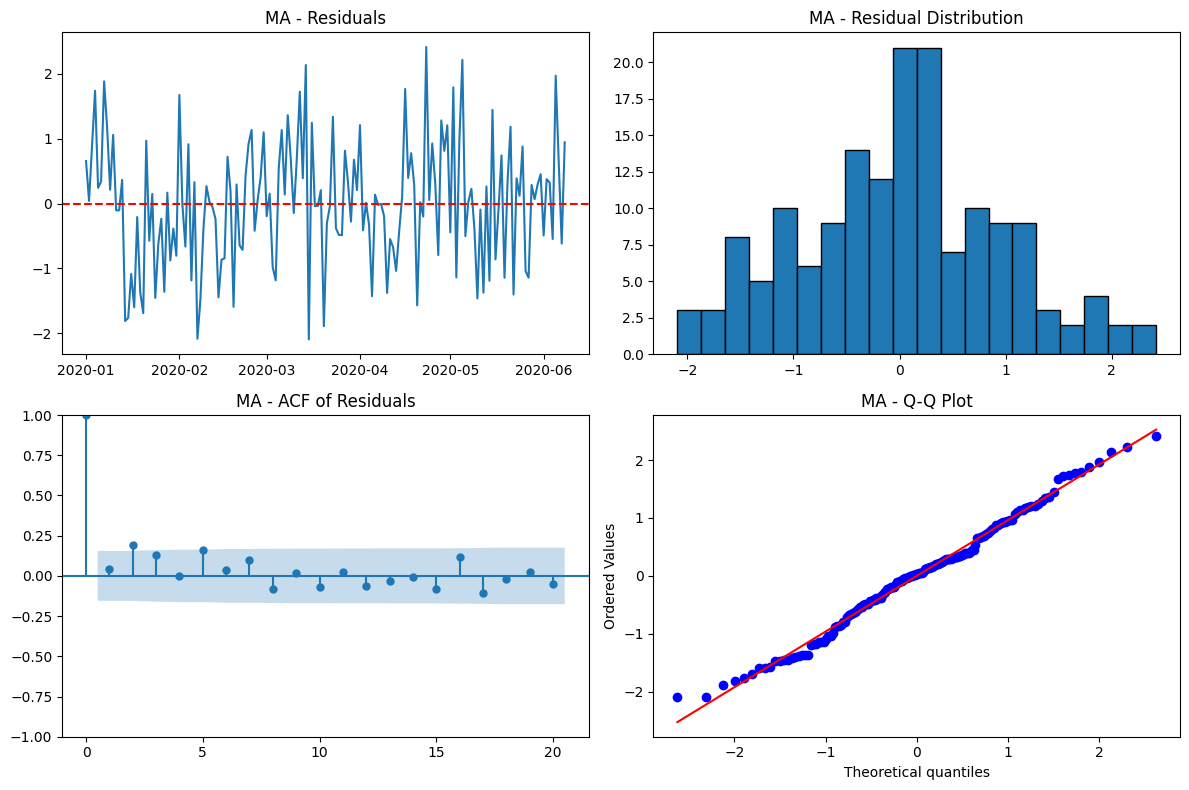


MA - Ljung-Box Test Results:
      lb_stat  lb_pvalue
10  17.440179   0.065174
20  25.041065   0.199865

Checking residuals for ARMA model:


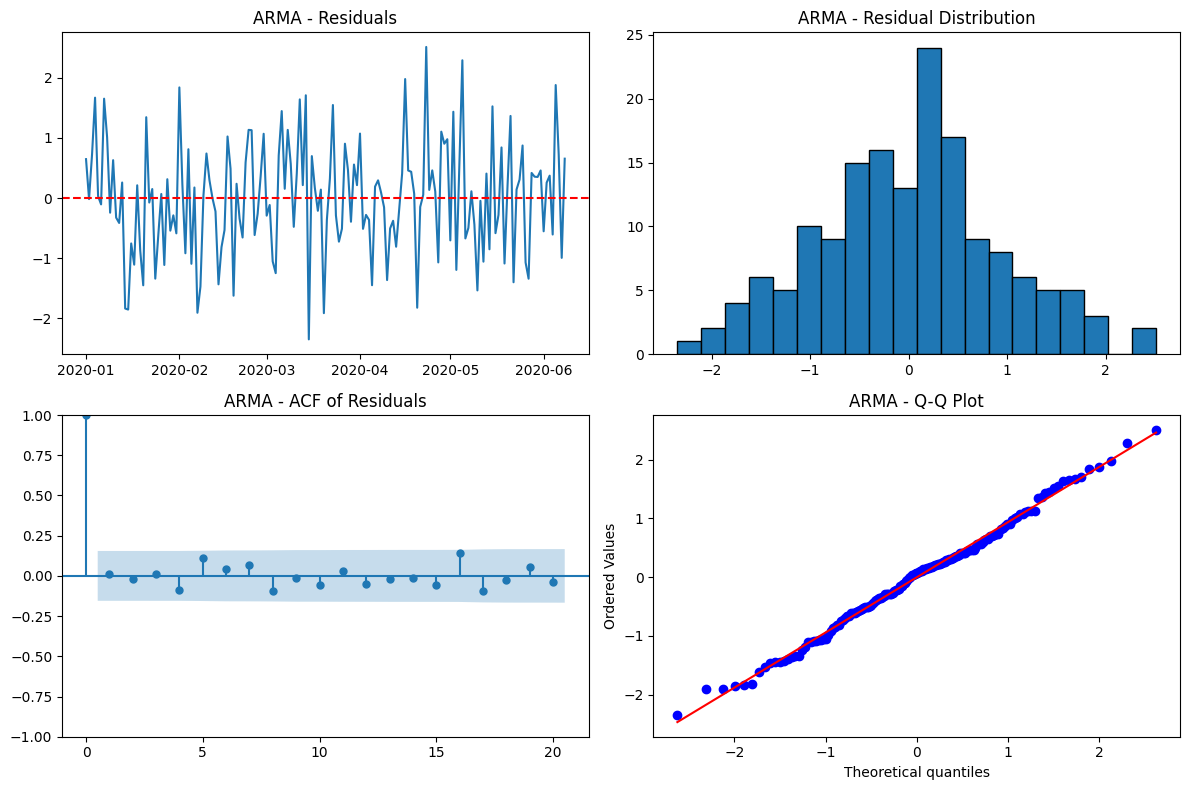


ARMA - Ljung-Box Test Results:
      lb_stat  lb_pvalue
10   6.661338   0.756983
20  13.970108   0.832008

Checking residuals for ARIMA model:


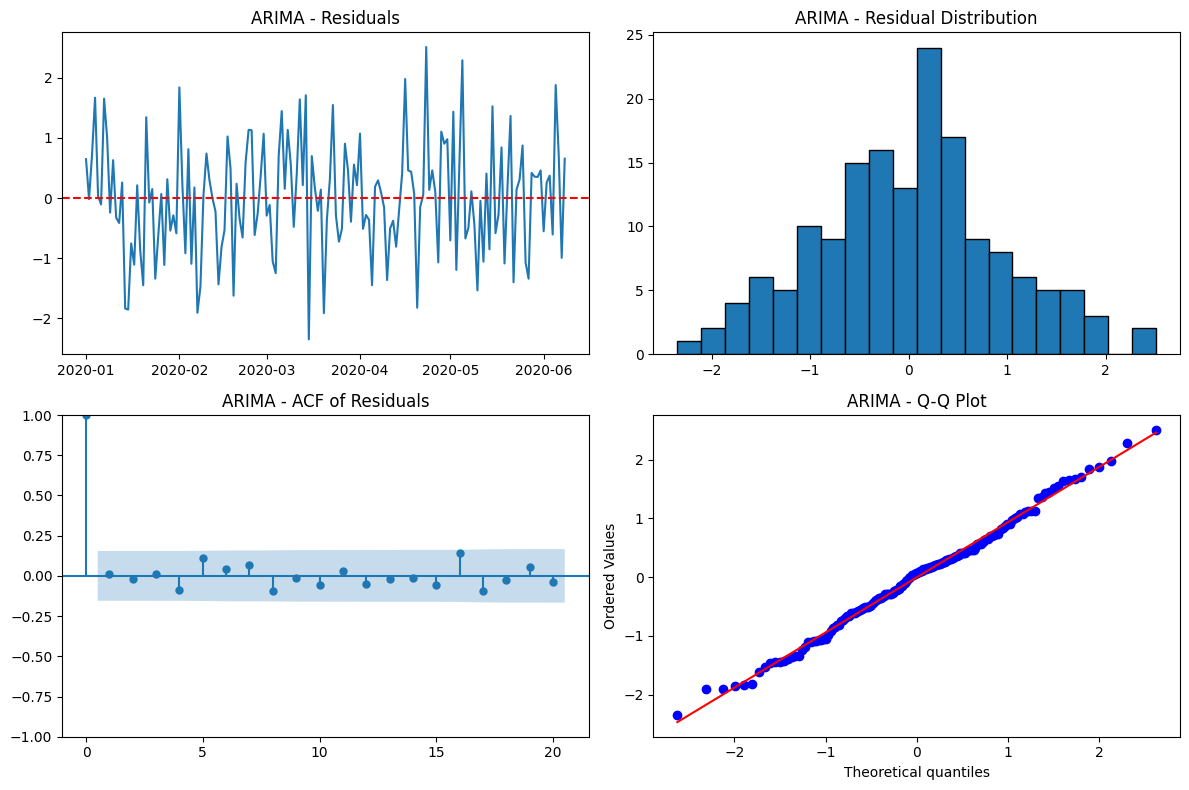


ARIMA - Ljung-Box Test Results:
      lb_stat  lb_pvalue
10   6.661338   0.756983
20  13.970108   0.832008

STEP 6: Model Comparison
----------------------------------------

Model Performance Comparison:
Model        AIC        BIC     RMSE         Order
   AR 437.256578 446.463291 1.097238         p=[1]
   MA 444.356471 453.581992 1.097873           q=1
 ARMA 438.416679 450.717374 1.082810      p=1, q=1
ARIMA 438.416679 450.717374 1.082810 p=1, d=0, q=1

Best Model by RMSE: ARMA (RMSE: 1.0828)
Best Model by AIC: AR (AIC: 437.26)

Results saved to 'model_comparison_results.csv'


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

def load_and_prepare_data(file_path=None):
    """
    Load time series data - either from file or generate sample data
    """
    if file_path:
        # Load your data here (adjust based on your file format)
        data = pd.read_csv(file_path, parse_dates=True, index_col=0)
        ts_data = data.iloc[:, 0]  # Assuming first column is the time series
    else:
        # Generate sample ARIMA data for demonstration
        n_points = 200
        # ARIMA(1,1,1) process
        ar_params = np.array([0.7])
        ma_params = np.array([-0.3])

        # Generate ARIMA series
        from statsmodels.tsa.arima_process import ArmaProcess
        ar = np.r_[1, -ar_params]
        ma = np.r_[1, ma_params]
        arma_process = ArmaProcess(ar, ma)
        ts_data = arma_process.generate_sample(nsample=n_points)
        ts_data = pd.Series(ts_data, index=pd.date_range(start='2020-01-01', periods=n_points, freq='D'))

    return ts_data

def check_stationarity(timeseries, title):
    """
    Perform ADF test for stationarity
    """
    # ADF test
    result = adfuller(timeseries.dropna())

    print(f'\n{title} - Augmented Dickey-Fuller Test:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')

    if result[1] <= 0.05:
        print("=> Series is stationary")
        return True
    else:
        print("=> Series is non-stationary")
        return False

def identify_arima_order(ts_data, max_lags=20):
    """
    Identify potential ARIMA orders using ACF and PACF
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Original series
    axes[0, 0].plot(ts_data)
    axes[0, 0].set_title('Original Time Series')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('Value')

    # ACF of original series
    plot_acf(ts_data, ax=axes[0, 1], lags=max_lags)
    axes[0, 1].set_title('Autocorrelation Function')

    # Differenced series if needed
    ts_diff = ts_data.diff().dropna()

    # PACF of differenced series
    plot_pacf(ts_diff, ax=axes[1, 0], lags=max_lags, method='ywm')
    axes[1, 0].set_title('Partial Autocorrelation Function (Differenced)')

    # ACF of differenced series
    plot_acf(ts_diff, ax=axes[1, 1], lags=max_lags)
    axes[1, 1].set_title('Autocorrelation Function (Differenced)')

    plt.tight_layout()
    plt.show()

    return ts_diff

def fit_and_evaluate_models(ts_data, train_size=0.8):
    """
    Fit different time series models and compare their performance
    """
    # Split data into train and test
    split_point = int(len(ts_data) * train_size)
    train, test = ts_data[:split_point], ts_data[split_point:]

    models = {}
    results = []

    print("\n" + "="*60)
    print("FITTING DIFFERENT TIME SERIES MODELS")
    print("="*60)

    # 1. AR Model
    try:
        # Determine AR order using PACF
        pacf_values = pacf(train, nlags=20, method='ywm')
        ar_order = np.where(np.abs(pacf_values[1:]) > 1.96/np.sqrt(len(train)))[0]
        ar_order = ar_order[0] + 1 if len(ar_order) > 0 else 1

        ar_model = AutoReg(train, lags=min(ar_order, 10)).fit()
        ar_pred = ar_model.predict(start=len(train), end=len(ts_data)-1)
        ar_rmse = np.sqrt(np.mean((test.values - ar_pred.values)**2))
        models['AR'] = ar_model
        results.append({
            'Model': 'AR',
            'AIC': ar_model.aic,
            'BIC': ar_model.bic,
            'RMSE': ar_rmse,
            'Order': f'p={ar_model.ar_lags}'
        })
        print(f"\nAR Model (Order {ar_model.ar_lags}):")
        print(f"AIC: {ar_model.aic:.2f}, BIC: {ar_model.bic:.2f}, RMSE: {ar_rmse:.4f}")
    except Exception as e:
        print(f"AR model failed: {e}")

    # 2. MA Model
    try:
        # MA model as ARIMA(0,0,q)
        acf_values = acf(train, nlags=20)
        ma_order = np.where(np.abs(acf_values[1:]) > 1.96/np.sqrt(len(train)))[0]
        ma_order = ma_order[0] + 1 if len(ma_order) > 0 else 1

        ma_model = ARIMA(train, order=(0, 0, min(ma_order, 5))).fit()
        ma_pred = ma_model.forecast(steps=len(test))
        ma_rmse = np.sqrt(np.mean((test.values - ma_pred)**2))
        models['MA'] = ma_model
        results.append({
            'Model': 'MA',
            'AIC': ma_model.aic,
            'BIC': ma_model.bic,
            'RMSE': ma_rmse,
            'Order': f'q={ma_model.model_orders["ma"]}'
        })
        print(f"\nMA Model (Order q={ma_model.model_orders['ma']}):")
        print(f"AIC: {ma_model.aic:.2f}, BIC: {ma_model.bic:.2f}, RMSE: {ma_rmse:.4f}")
    except Exception as e:
        print(f"MA model failed: {e}")

    # 3. ARMA Model
    try:
        arma_model = ARIMA(train, order=(1, 0, 1)).fit()
        arma_pred = arma_model.forecast(steps=len(test))
        arma_rmse = np.sqrt(np.mean((test.values - arma_pred)**2))
        models['ARMA'] = arma_model
        results.append({
            'Model': 'ARMA',
            'AIC': arma_model.aic,
            'BIC': arma_model.bic,
            'RMSE': arma_rmse,
            'Order': 'p=1, q=1'
        })
        print(f"\nARMA Model (p=1, q=1):")
        print(f"AIC: {arma_model.aic:.2f}, BIC: {arma_model.bic:.2f}, RMSE: {arma_rmse:.4f}")
    except Exception as e:
        print(f"ARMA model failed: {e}")

    # 4. ARIMA Model with automatic order selection
    try:
        # Try different orders and select best by AIC
        best_aic = np.inf
        best_order = None
        best_arima_model = None

        # Simplified grid search
        for p in range(3):
            for d in range(2):
                for q in range(3):
                    try:
                        model = ARIMA(train, order=(p, d, q)).fit()
                        if model.aic < best_aic:
                            best_aic = model.aic
                            best_order = (p, d, q)
                            best_arima_model = model
                    except:
                        continue

        if best_arima_model:
            arima_pred = best_arima_model.forecast(steps=len(test))
            arima_rmse = np.sqrt(np.mean((test.values - arima_pred)**2))
            models['ARIMA'] = best_arima_model
            results.append({
                'Model': 'ARIMA',
                'AIC': best_arima_model.aic,
                'BIC': best_arima_model.bic,
                'RMSE': arima_rmse,
                'Order': f'p={best_order[0]}, d={best_order[1]}, q={best_order[2]}'
            })
            print(f"\nARIMA Model (Order {best_order}):")
            print(f"AIC: {best_arima_model.aic:.2f}, BIC: {best_arima_model.bic:.2f}, RMSE: {arima_rmse:.4f}")
    except Exception as e:
        print(f"ARIMA model failed: {e}")

    # Create comparison DataFrame
    results_df = pd.DataFrame(results)

    # Plot predictions vs actual
    plt.figure(figsize=(12, 6))
    plt.plot(train.index, train, label='Training Data', color='blue')
    plt.plot(test.index, test, label='Actual Test Data', color='green')

    colors = ['red', 'purple', 'orange', 'brown']
    for i, (name, model) in enumerate(models.items()):
        if name == 'AR':
            pred = model.predict(start=len(train), end=len(ts_data)-1)
            plt.plot(test.index, pred, label=f'{name} Predictions', color=colors[i], linestyle='--')
        else:
            pred = model.forecast(steps=len(test))
            plt.plot(test.index, pred, label=f'{name} Predictions', color=colors[i], linestyle='--')

    plt.title('Model Predictions vs Actual Values')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return models, results_df

def print_model_equation(model, model_name):
    """
    Print the mathematical equation of the fitted model with coefficients
    """
    print(f"\n{model_name} Model Equation:")
    print("-" * 40)

    if model_name == 'AR':
        # AR model equation
        params = model.params
        ar_params = params[1:]  # Excluding constant
        const = params[0] if 'const' in params.index else 0

        equation = f"Y_t = {const:.4f}"
        for i, coef in enumerate(ar_params):
            equation += f" + {coef:.4f}Y_{{t-{i+1}}}"
        equation += " + ε_t"
        print(equation)

    elif model_name in ['MA', 'ARMA', 'ARIMA']:
        # ARIMA/ARMA/MA model equation
        params = model.params

        # Get AR and MA parameters
        ar_params = []
        ma_params = []
        const = 0

        for name, value in params.items():
            if 'ar.L' in name:
                ar_params.append(value)
            elif 'ma.L' in name:
                ma_params.append(value)
            elif 'const' in name:
                const = value

        # Build equation
        if model_name == 'MA':
            equation = f"Y_t = {const:.4f} + ε_t"
            for i, coef in enumerate(ma_params):
                equation += f" + {coef:.4f}ε_{{t-{i+1}}}"
        else:
            # ARMA or ARIMA
            equation = f"Y_t = {const:.4f}"
            for i, coef in enumerate(ar_params):
                equation += f" + {coef:.4f}Y_{{t-{i+1}}}"
            equation += " + ε_t"
            for i, coef in enumerate(ma_params):
                equation += f" + {coef:.4f}ε_{{t-{i+1}}}"

        # Add differencing info for ARIMA
        if model_name == 'ARIMA' and hasattr(model, 'model'):
            d = model.model.order[1]
            if d > 0:
                print(f"(With {d} order differencing: ΔY_t = Y_t - Y_{{t-1}})")

        print(equation)

    # Print parameter significance if available
    if hasattr(model, 'pvalues'):
        print("\nParameter Significance:")
        for name, pval in model.pvalues.items():
            sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
            print(f"  {name}: {model.params[name]:.4f} (p={pval:.4f}){sig}")

def check_residuals(model, model_name):
    """
    Check if residuals are white noise
    """
    residuals = model.resid

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Residuals over time
    axes[0, 0].plot(residuals)
    axes[0, 0].set_title(f'{model_name} - Residuals')
    axes[0, 0].axhline(y=0, color='r', linestyle='--')

    # Histogram of residuals
    axes[0, 1].hist(residuals, bins=20, edgecolor='black')
    axes[0, 1].set_title(f'{model_name} - Residual Distribution')

    # ACF of residuals
    plot_acf(residuals, ax=axes[1, 0], lags=20)
    axes[1, 0].set_title(f'{model_name} - ACF of Residuals')

    # Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f'{model_name} - Q-Q Plot')

    plt.tight_layout()
    plt.show()

    # Ljung-Box test
    lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
    print(f"\n{model_name} - Ljung-Box Test Results:")
    print(lb_test)

# Main execution
def main():
    print("="*60)
    print("BOX-JENKINS METHODOLOGY FOR TIME SERIES ANALYSIS")
    print("="*60)

    # Step 1: Load data
    print("\nSTEP 1: Loading Time Series Data")
    print("-"*40)
    # Replace with your file path or use generated data
    ts_data = load_and_prepare_data()  # Add file_path='your_data.csv' to load actual data
    print(f"Data loaded: {len(ts_data)} observations")
    print(f"Date range: {ts_data.index[0]} to {ts_data.index[-1]}")

    # Step 2: Check stationarity
    print("\nSTEP 2: Testing for Stationarity")
    print("-"*40)
    is_stationary = check_stationarity(ts_data, "Original Series")

    # Step 3: Identification
    print("\nSTEP 3: Model Identification")
    print("-"*40)
    ts_diff = identify_arima_order(ts_data)

    if not is_stationary:
        print("\nApplying differencing to achieve stationarity...")
        check_stationarity(ts_diff, "Differenced Series")

    # Step 4: Estimation and Model Fitting
    print("\nSTEP 4: Model Estimation and Fitting")
    print("-"*40)
    models, results_df = fit_and_evaluate_models(ts_data)

    ## modelequestions
    for model_name, model in models.items():
        print_model_equation(model, model_name)

    # Step 5: Diagnostic Checking
    print("\nSTEP 5: Diagnostic Checking")
    print("-"*40)
    for model_name, model in models.items():
        print(f"\nChecking residuals for {model_name} model:")
        check_residuals(model, model_name)

    # Step 6: Model Comparison
    print("\nSTEP 6: Model Comparison")
    print("-"*40)
    print("\nModel Performance Comparison:")
    print(results_df.to_string(index=False))

    # Identify best model based on RMSE and AIC
    if not results_df.empty:
        best_rmse = results_df.loc[results_df['RMSE'].idxmin()]
        best_aic = results_df.loc[results_df['AIC'].idxmin()]

        print(f"\nBest Model by RMSE: {best_rmse['Model']} (RMSE: {best_rmse['RMSE']:.4f})")
        print(f"Best Model by AIC: {best_aic['Model']} (AIC: {best_aic['AIC']:.2f})")

        # Save results to CSV
        results_df.to_csv('model_comparison_results.csv', index=False)
        print("\nResults saved to 'model_comparison_results.csv'")

if __name__ == "__main__":
    main()